## Artificial Neuron
A single neuron takes n inputs x1, x2... xn, applies weighted sum plus bias and then passes it through non linear activation function.

## Multi Layer Perceptron
MLP stacks L layers of Perceptrons. Each layer may consist of n number of perceptron, A MLP has input layer, multiple hidden layers and a output layers.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module): #fully connected feed forward network
  def __init__(self, layers, activation=nn.ReLU(), dropout=0.0):
    super().__init__()
    self.activation = activation
    self.dropout = nn.Dropout(p=dropout)

    blocks = []

    for i in range(len(layers) -1):
      blocks.append(nn.Linear(layers[i], layers[i+1]))
      if i < len(layers) - 2:
        blocks.append(activation)
        if dropout > 0:
          blocks.append(nn.Dropout(p=dropout))

    self.net = nn.Sequential(*blocks)

    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity = 'relu')
        nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.net(x)

model = MLP([28**2, 512, 256, 10], activation=nn.ReLU(), dropout=0.2)
x=torch.randn(10, 28**2)
y=model(x)
print(y.shape)


torch.Size([10, 10])


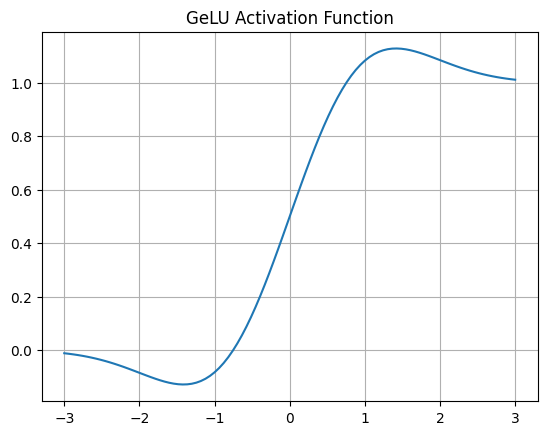

In [ ]:
#activation functions

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

z = torch.linspace(-3, 3, 100)

activations = {
    'relu' : F.relu(z) ,
    'tanh' : torch.tanh(z) ,
    'sigmoid' : torch.sigmoid(z) ,
    'softmax' : torch.softmax(z, dim= 0),
    'Gelu' : F.gelu(z),
}

z_g = z.clone().requires_grad_(True)
y = F.gelu(z_g)
y.sum().backward()
gelu_grad = z_g.grad

plt.plot(z_g.detach().numpy(), gelu_grad.detach().numpy(), label='Gelu Gradient')
plt.title("GeLU Activation Function")
plt.grid(True)
plt.show()

## Losses in DL

**Regression Losses:** Mean Squared Error(MSE), Mean Absolute Error(MAE), Huber Loss: MSE + MAE

**Classification Losses:** Binary Cross Entropy, Categroical Cross-Emtropy

**important:** In Pytorch, Softmax function doesn't directly instead we have cross-entropy-loss = LogSoftmac +NLLLoss, we don't apply softmax

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn # Ensure nn is imported

x = torch.linspace(-3, 3, 100)

mse = nn.MSELoss()
mae = nn.L1Loss()
huber = nn.HuberLoss(delta = 1.0)

bce = nn.BCEWithLogitsLoss() #expects raw logits
ce = nn.CrossEntropyLoss() #expects raw logits

logits = torch.randn(32, 10)

# For regression losses (MSE, MAE, Huber), labels should match logits shape
# Assuming multi-output regression where each sample has 10 target values
labels_regression = torch.randn(32, 10)
mse_loss = mse(logits, labels_regression)
mae_loss = mae(logits, labels_regression)
huber_loss = huber(logits, labels_regression)
print(f'{mse_loss},{mae_loss},{huber_loss}')
# For Binary Cross Entropy (BCEWithLogitsLoss), labels should be binary (0 or 1)
# and match logits shape for multi-label classification
labels_bce = torch.randint(0, 2, (32, 10)).float() # .float() is important for BCE target
bce_loss = bce(logits, labels_bce)
print(f'{bce_loss}')

# For Cross Entropy (CrossEntropyLoss), labels should be class indices (0 to num_classes-1)
# and have shape (batch_size,) for multi-class classification
labels_ce = torch.randint(0, 10, (32,))
ce_loss = ce(logits, labels_ce)
print(f'{ce_loss}')

1.8486969470977783,1.0742671489715576,0.6720840930938721
0.7828562259674072
2.623969316482544


In [ ]:
def init_weights(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_normal_(module.weight, nonlinearity = 'relu')
    nn.init.zeros_(module.bias)
  elif isinstance(module, nn.Embedding):
    nn.init.normal_(module.weight, mean=0.0, std=0.02)
  elif isinstance(module, nn.LayerNorm):
    nn.init.ones_(module.weight)
    nn.init.zeros_(module.bias)
model = MLP([784, 512, 256, 101])
model.apply(init_weights)


MLP(
  (activation): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=101, bias=True)
  )
)

sooo
Xavier Functions are used initialize the weights and biases when the functions like tanh/sigmoid are used.
while using relu, kaimling function is used to initialize weight and biases.

weight and biases are initialized to keep the gradients and activation stable.



##optimizers
-optimizers are the engine that minimize the loss function. some common are SGD, Adam, AdamW.
-to use an optmizer, you need to import torch.optim, it consists the optimizers.
-they take it model parameters, lr, momentum/Betas, weight decay/eps as their parameters


## Regularization

**Dropout**: during training zero zero our each neuron output with probability p.
at inference, disable dropout and scale by (1-p)

**Batch Normalization** Normalize activations with each minibatch.

**Layer Normalization** Normalize across feature dimension.